In [2]:
import pandas as pd
import numpy as np

df = pd.read_excel("../data/Estudio_mercado_aroma_corregido.xlsx")

df.head()

,ESTABLECIMIENTO,PRODUCTO,MARCA,PRESENTACION,GRAMAJE,PRECIO,Aroma,Frentes,Nivel de percha,promoción,Unnamed: 10
0,EMPROVIT,Jabón liquido,Jolly,Botella,500ml,1.80,Floral,1.0,superior,NaN,NaN
1,EMPROVIT,Jabón liquido,ONLY,Botella,1LT,1.45,Bambú,1.0,superior,NaN,NaN
2,EMPROVIT,Jabón liquido,ONLY,Botella,250ml,0.86,Naranja,2.0,superior,NaN,NaN
3,EMPROVIT,Jabón liquido,Sarys,Doypack,1LT,1.75,Vainilla exótica,1.0,superior,NaN,NaN
4,EMPROVIT,Desinfectante,Kalipto,Botella,2LT,4.15,Naranja+Limón con bicarbonato,1.0,Inferior,NaN,NaN


In [3]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ESTABLECIMIENTO  976 non-null    object 
 1   PRODUCTO         976 non-null    object 
 2   MARCA            976 non-null    object 
 3   PRESENTACION     976 non-null    object 
 4   GRAMAJE          976 non-null    object 
 5   PRECIO           957 non-null    float64
 6   Aroma            871 non-null    object 
 7   Frentes          960 non-null    float64
 8   Nivel de percha  976 non-null    object 
 9   promoción        199 non-null    object 
 10  Unnamed: 10      3 non-null      object 
dtypes: float64(2), object(9)
memory usage: 84.0+ KB


,ESTABLECIMIENTO,PRODUCTO,MARCA,PRESENTACION,GRAMAJE,PRECIO,Aroma,Frentes,Nivel de percha,promoción,Unnamed: 10
count,976,976,976,976,976,957.000000,871,960.000000,976,199,3
unique,9,14,107,7,79,NaN,166,NaN,13,96,3
top,CORAL,Desinfectante,Olimpia,Botella,1lt,NaN,floral,NaN,ojos,oferta el 15% 0.85 pvp,triple accion
freq,246,359,79,683,154,NaN,84,NaN,230,26,1
mean,NaN,NaN,NaN,NaN,NaN,2.888443,NaN,2.275000,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,2.654832,NaN,1.755492,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.170000,NaN,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1.010000,NaN,1.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,2.200000,NaN,2.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,3.750000,NaN,3.000000,NaN,NaN,NaN


In [4]:
df.shape

(976, 11)

LIMPIEZA DE DATOS

In [5]:
df = df.drop(columns=["Unnamed: 10"])

In [6]:
df.columns

Index(['ESTABLECIMIENTO', 'PRODUCTO', 'MARCA', 'PRESENTACION', 'GRAMAJE',
       'PRECIO', 'Aroma', 'Frentes', 'Nivel de percha', 'promoción'],
      dtype='object')

In [7]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [8]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip().str.lower()

In [9]:
df["precio"].isna().sum()

np.int64(19)

Manejo de aromas nulos

In [10]:
df = df.dropna(subset=["precio"])

In [11]:
df.shape

(957, 10)

In [12]:
df["frentes"] = df["frentes"].fillna(0)

Tratamiento de aroma

In [12]:
df.loc[
    (df["producto"] == "cloro") & (df["aroma"].isna()),
    "aroma"
] = "original"

In [13]:
df["aroma"] = df["aroma"].fillna("no_especificado")

Limpieza de gramaje

In [14]:
df["gramaje"] = df["gramaje"].str.strip().str.lower()

In [15]:
df["gramaje"] = df["gramaje"].replace({
    "1lt": "1l",
    "1 gl": "1gl",
    "2.lt": "2lt"
})

Clasificar tipo de medida

In [16]:
def clasificar_medida(x):
    if pd.isna(x):
        return "desconocido"
    elif "*" in x:
        return "multipack"
    elif "ml" in x or "l" in x or "gl" in x:
        return "volumen"
    elif "g" in x or "kg" in x or "gr" in x:
        return "peso"
    elif "unidad" in x:
        return "unidades"
    else:
        return "otro"

df["tipo_medida"] = df["gramaje"].apply(clasificar_medida)

In [17]:
df["tipo_medida"].value_counts()

tipo_medida
volumen        907
peso            31
desconocido     12
unidades         6
multipack        1
Name: count, dtype: int64

Limpieza de frentes

In [18]:
df["frentes"].isna().sum()

np.int64(16)

In [19]:
df["frentes"] = df["frentes"].fillna(0)

Convertir nivel de percha en variable ordinal

In [20]:
df["nivel_de_percha"] = df["nivel_de_percha"].replace({
    "inferior": 1,
    "medio": 2,
    "superior": 3
})

Revisar duplicados

In [21]:
df.duplicated().sum()

np.int64(13)

In [22]:
df = df.drop_duplicates()

In [ ]:
Guardar versión limpia

In [23]:
df.to_csv("../data/cleaned_market_data.csv", index=False)

ANÁLISIS DE AROMAS

🎯 Objetivos

Validar si fresa es viable en desinfectante.

Detectar aromas dominantes.

Identificar oportunidades no saturadas.

In [24]:
df_aromas = df[df["producto"].isin(["desinfectante", "jabón liquido"])]

In [25]:
frecuencia_aromas = (
    df_aromas.groupby(["producto", "aroma"])
    .size()
    .reset_index(name="frecuencia")
    .sort_values(["producto", "frecuencia"], ascending=[True, False])
)

frecuencia_aromas.head(20)

,producto,aroma,frecuencia
22,desinfectante,lavanda,94
11,desinfectante,eucalipto,72
15,desinfectante,floral,31
31,desinfectante,manzana verde,28
29,desinfectante,manzana canela,24
37,desinfectante,naranja,17
28,desinfectante,manzana,12
8,desinfectante,citronela,11
21,desinfectante,frutilla,11
19,desinfectante,frescura marina,10


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_11684\1865608665.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


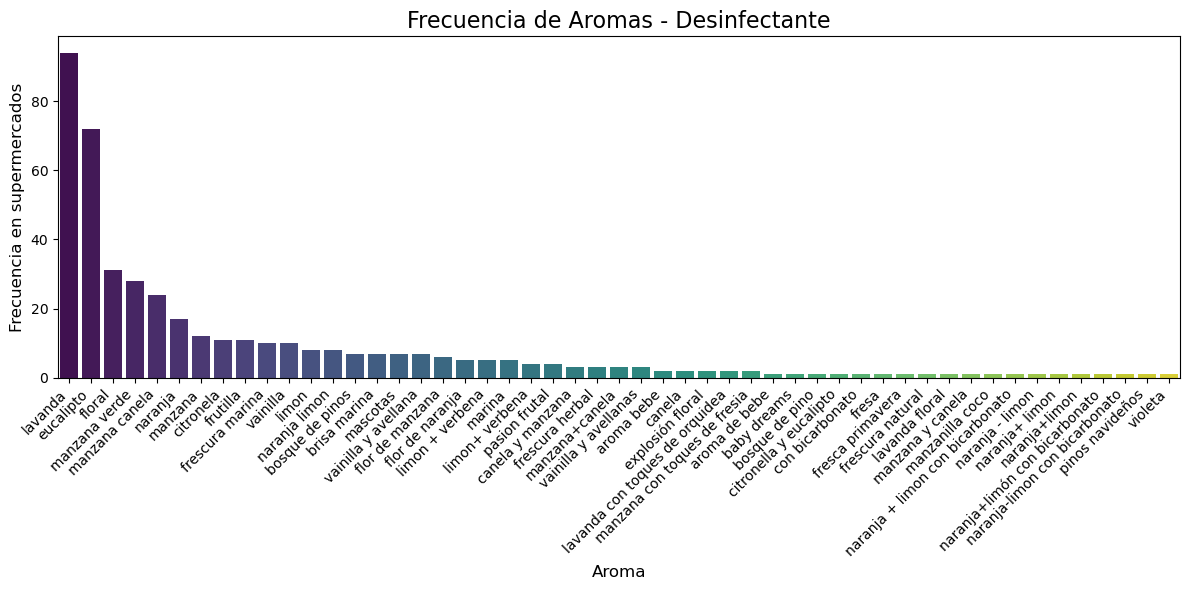

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que ya tienes frecuencia_aromas
# Seleccionamos solo desinfectante para el gráfico
df_desinfectante = frecuencia_aromas[frecuencia_aromas["producto"] == "desinfectante"]

# Ordenamos de mayor a menor frecuencia
df_desinfectante = df_desinfectante.sort_values("frecuencia", ascending=False)

# Creamos gráfico de barras
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_desinfectante,
    x="aroma",
    y="frecuencia",
    palette="viridis"  # Puedes cambiar el color
)

# Ajustes de estética
plt.title("Frecuencia de Aromas - Desinfectante", fontsize=16)
plt.xlabel("Aroma", fontsize=12)
plt.ylabel("Frecuencia en supermercados", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("../images/frecuencia_aromas_desinfectante.png", dpi=300)
# Mostrar gráfico
plt.show()

Interpretación general

* Aromas más frecuentes (líderes claros)

Lavanda es el aroma más común, con una frecuencia muy superior al resto.

Le siguen eucalipto y floral, también con alta presencia.
 Esto indica que los supermercados priorizan aromas asociados con sensación de limpieza, frescura y desinfección tradicional.

Segundo grupo de preferencia

* Aromas como manzana, naranja, limón y combinaciones cítricas aparecen con frecuencia moderada.

 Los cítricos son populares porque se asocian con energía, frescura y efecto antibacterial percibido.

* Aromas de frecuencia media-baja

Fragancias como vainilla, pino, brisa marina, hierbabuena, entre otras, tienen presencia menor pero constante.
Representan opciones de diversificación para consumidores que buscan algo diferente al clásico aroma de limpieza.

* Aromas poco frecuentes (larga cola)

Combinaciones específicas (por ejemplo, mezclas de frutas o aromas más exóticos) aparecen con muy baja frecuencia.
Esto sugiere que son productos de nicho o pruebas de mercado.

- Conclusión

El mercado de desinfectantes está claramente dominado por aromas tradicionales y asociados psicológicamente con limpieza (lavanda y eucalipto).
Los aromas cítricos ocupan el segundo lugar en preferencia, mientras que las fragancias más innovadoras o combinadas tienen una presencia mucho menor.

Si quieres, puedo ayudarte a convertir esta interpretación en un análisis más formal para un informe o presentación.

Tamaños dominan por aroma

In [52]:
# Filtrar solo desinfectante
df_desinfectante = df[df["producto"] == "desinfectante"]

# Agrupar por aroma, presentación y gramaje
analisis_presentacion = (
    df_desinfectante.groupby(["aroma", "presentacion", "gramaje"])
    .agg(
        frecuencia=("marca", "count"),        # cuántos productos hay
        frentes_promedio=("frentes", "mean"), # visibilidad promedio
        precio_promedio=("precio", "mean")    # precio promedio
    )
    .reset_index()
    .sort_values(["frecuencia"], ascending=False)
)

analisis_presentacion.head(20)

,aroma,presentacion,gramaje,frecuencia,frentes_promedio,precio_promedio
76,lavanda,botella,1l,29,2.551724,1.655862
28,eucalipto,botella,1l,23,1.913043,1.651304
51,floral,botella,1l,12,2.000000,1.658333
80,lavanda,botella,2lt,11,2.363636,3.551818
37,eucalipto,botella,900ml,10,1.600000,1.786000
75,lavanda,botella,1gl,8,1.500000,5.548750
27,eucalipto,botella,1gl,8,1.375000,5.722500
86,lavanda,botella,900ml,8,1.625000,1.741250
32,eucalipto,botella,2lt,7,3.714286,3.867143
124,manzana verde,botella,2lt,7,1.428571,3.817143


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_11684\2338398099.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


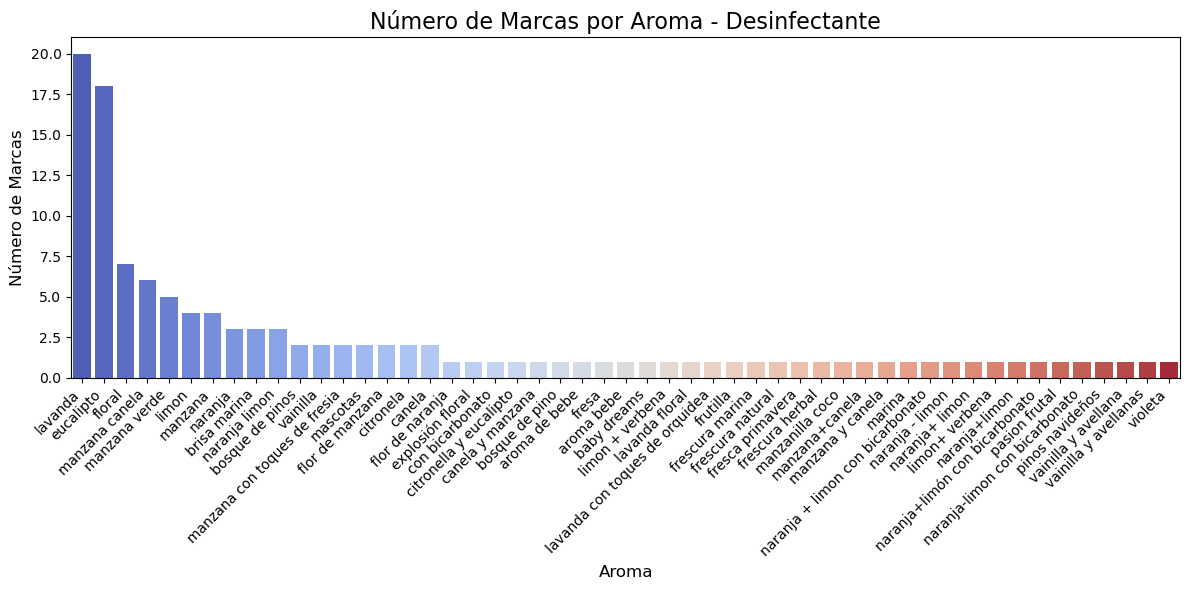

In [54]:
# Filtramos solo desinfectante
df_desinfectante_marcas = marcas_por_aroma[marcas_por_aroma["producto"] == "desinfectante"]
df_desinfectante_marcas = df_desinfectante_marcas.sort_values("numero_marcas", ascending=False)

# Crear gráfico
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_desinfectante_marcas,
    x="aroma",
    y="numero_marcas",
    palette="coolwarm"
)

plt.title("Número de Marcas por Aroma - Desinfectante", fontsize=16)
plt.xlabel("Aroma", fontsize=12)
plt.ylabel("Número de Marcas", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Guardar gráfico
plt.savefig("../images/marcas_por_aroma_desinfectante.png", dpi=300)
plt.show()

Descripción e interpretación

* Aromas con mayor presencia de marcas

Lavanda lidera claramente con el mayor número de marcas (alrededor de 20).

Le sigue eucalipto con una participación también alta (cerca de 18 marcas).
  Esto indica que estos aromas no solo son los más frecuentes, sino también los más competitivos, ya que muchas marcas ofrecen productos con estas fragancias.

* Aromas con presencia intermedia

Fragancias como floral, manzana verde, manzana, limón y naranja cuentan con entre 4 y 7 marcas aproximadamente.
 Representan opciones populares dentro del mercado, aunque con menor diversidad de oferta en comparación con lavanda y eucalipto.

* Aromas con baja participación

Otros como pino, brisa marina, naraja-limón, bosque de pinos, entre otros, tienen entre 2 y 3 marcas.
 Esto sugiere que están presentes en el mercado, pero con menor variedad de fabricantes.

* Aromas de nicho

Existe un amplio grupo de aromas (principalmente combinaciones o fragancias más específicas) que cuentan con solo una marca disponible.
 Estos productos parecen estar dirigidos a segmentos específicos del consumidor o representan estrategias de diferenciación de ciertas marcas.

 CONCLUSION

El mercado de desinfectantes muestra una alta concentración de marcas en aromas tradicionales asociados con limpieza (como lavanda y eucalipto). En contraste, los aromas más innovadores o combinados presentan una oferta limitada, lo que evidencia oportunidades potenciales para la diferenciación de productos dentro de este segmento.

In [ ]:
Visibilidad (frentes promedio)

In [27]:
visibilidad = (
    df_aromas.groupby(["producto", "aroma"])["frentes"]
    .mean()
    .reset_index(name="frentes_promedio")
    .sort_values("frentes_promedio", ascending=False)
)

visibilidad.head(20)

,producto,aroma,frentes_promedio
7,desinfectante,canela y manzana,4.333333
24,desinfectante,lavanda floral,4.000000
38,desinfectante,naranja + limon con bicarbonato,3.000000
48,desinfectante,vainilla y avellana,2.571429
22,desinfectante,lavanda,2.372340
29,desinfectante,manzana canela,2.291667
11,desinfectante,eucalipto,2.083333
37,desinfectante,naranja,2.058824
15,desinfectante,floral,2.000000
3,desinfectante,bosque de pino,2.000000


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_11684\620602345.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


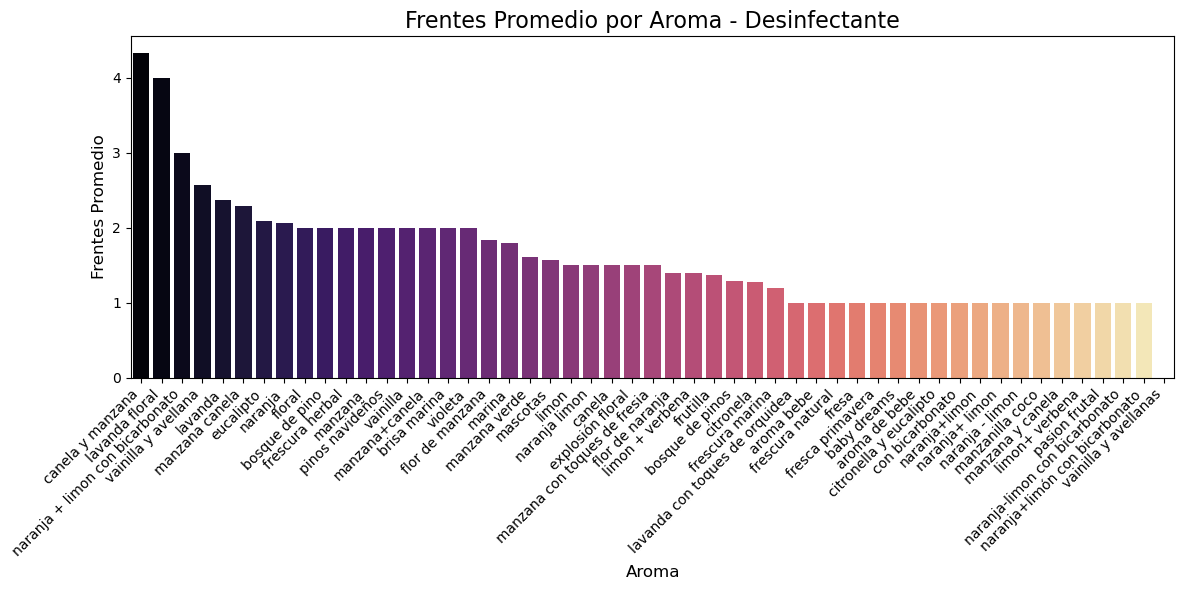

In [50]:
visibilidad_desinfectante = visibilidad[visibilidad["producto"] == "desinfectante"]
visibilidad_desinfectante = visibilidad_desinfectante.sort_values("frentes_promedio", ascending=False)

# Gráfico de desinfectante
plt.figure(figsize=(12,6))
sns.barplot(
    data=visibilidad_desinfectante,
    x="aroma",
    y="frentes_promedio",
    palette="magma"
)
plt.title("Frentes Promedio por Aroma - Desinfectante", fontsize=16)
plt.xlabel("Aroma", fontsize=12)
plt.ylabel("Frentes Promedio", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../images/frentes_promedio_desinfectante.png", dpi=300)
plt.show()

Descripción e interpretación

* Aromas con mayor espacio en góndola

Fragancias como canela y manzana presentan el mayor número de frentes promedio (alrededor de 4).

Le siguen combinaciones como naranja + limón con bicarbonato y vainilla y almendra, con promedios cercanos a 3.
 Esto indica que, aunque no necesariamente son los más comunes, estos aromas reciben mayor visibilidad en el punto de venta, posiblemente por estrategias de promoción o posicionamiento premium.

* Aromas con espacio intermedio

Aromas tradicionales como lavanda, manzana, eucalipto, limón y floral cuentan con entre 2 y 2.5 frentes promedio.
 Esto refleja una presencia estable en góndola, acorde a su alta rotación y demanda constante.

* Aromas con menor exhibición

Fragancias como brisa marina, pino, frescura natural, entre otros, tienen entre 1 y 1.5 frentes.
 Aunque están disponibles, su visibilidad es más limitada, lo que puede afectar su rotación.

* Aromas con mínima asignación de espacio

Varias combinaciones específicas o aromas de nicho cuentan con solo 1 frente promedio.
 Esto sugiere que son productos de baja demanda o con distribución más restringida.

 Conclusión

El espacio en góndola no siempre está directamente relacionado con la frecuencia o el número de marcas disponibles. Algunos aromas menos comunes reciben mayor número de frentes, lo que podría responder a estrategias comerciales, promociones o intentos de incentivar su rotación. En cambio, los aromas tradicionales mantienen una exhibición moderada pero constante debido a su demanda estable.

In [57]:
desinfectante = df[df["producto"] == "desinfectante"].copy()
desinfectante["gramaje"] = desinfectante["gramaje"].str.strip().str.lower()

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar desinfectante y crear copia para evitar warnings
desinfectante = df[df["producto"] == "desinfectante"].copy()

# Normalizar gramaje
desinfectante["gramaje"] = desinfectante["gramaje"].str.strip().str.lower()

In [64]:
# Convertir columnas a tipo numérico
desinfectante["precio"] = pd.to_numeric(desinfectante["precio"], errors="coerce")
desinfectante["frentes"] = pd.to_numeric(desinfectante["frentes"], errors="coerce")
desinfectante["nivel_de_percha"] = pd.to_numeric(desinfectante["nivel_de_percha"], errors="coerce")

In [65]:
gramaje_resumen = desinfectante.groupby("gramaje").agg(
    frecuencia = ("marca", "count"),
    numero_marcas = ("marca", "nunique"),
    precio_promedio = ("precio", "mean"),
    frentes_promedio = ("frentes", "mean"),
    nivel_percha_promedio = ("nivel_de_percha", "mean")
).reset_index().sort_values("frecuencia", ascending=False)

gramaje_resumen

,gramaje,frecuencia,numero_marcas,precio_promedio,frentes_promedio,nivel_percha_promedio
2,1l,147,21,1.801701,1.829932,2.395349
9,2lt,55,7,3.833273,1.854545,1.761905
18,900ml,46,5,1.853043,1.673913,2.392857
7,240ml,39,3,0.622308,3.128205,2.214286
1,1gl,35,9,6.110571,1.314286,1.500000
14,500ml,34,8,0.980882,1.941176,1.750000
13,450ml,24,1,0.837917,1.833333,2.363636
11,3785ml,10,3,7.256000,1.600000,1.200000
8,250ml,8,3,0.453750,2.875000,2.500000
16,5lt,7,4,5.858571,2.000000,1.000000


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_11684\3750533657.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gramaje_resumen, x="gramaje", y="frecuencia", palette="Blues_d")


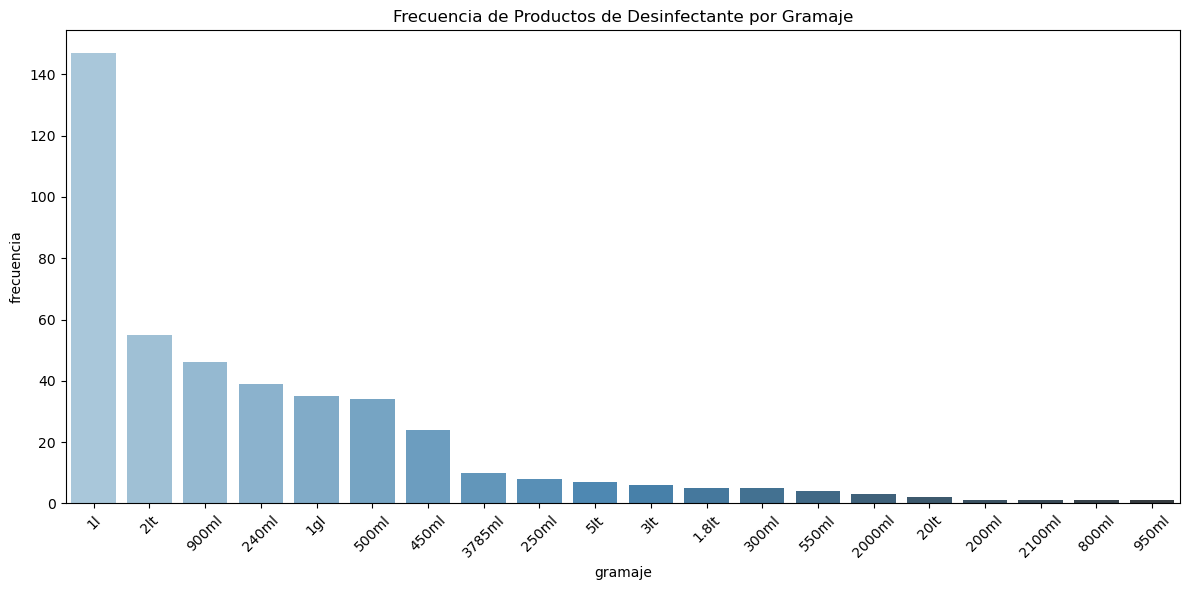

In [66]:
plt.figure(figsize=(12,6))
sns.barplot(data=gramaje_resumen, x="gramaje", y="frecuencia", palette="Blues_d")
plt.title("Frecuencia de Productos de Desinfectante por Gramaje")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/desinfectante_frecuencia_gramaje.png", dpi=300)
plt.show()

Productos más comunes:

El gramaje 1 litro (1L) domina ampliamente el mercado con casi 150 productos.

Le siguen 2 litros (2L) y 900 ml, con frecuencias mucho menores, pero aún significativas.

Tendencia general:

Hay una clara caída a medida que el gramaje disminuye o aumenta fuera de los tamaños comunes.

Esto indica que los consumidores y fabricantes prefieren tamaños estándar que son fáciles de manejar y vender.

Gramajes menos frecuentes:

Los tamaños como 200 ml, 2100 ml, 950 ml aparecen muy poco, lo que sugiere que son nichos o formatos especiales que no son los más populares en el mercado.

Interpretación comercial:

Los fabricantes que quieren entrar al mercado o lanzar nuevos productos deberían priorizar los tamaños de 1L y 2L, porque son los más frecuentes y probablemente los más demandados.

Los tamaños pequeños (200–500 ml) podrían apuntar a consumidores que buscan portabilidad o pruebas, mientras que los tamaños grandes (5L, 2100 ml) podrían estar orientados a uso institucional o industrial.

Precio promedio por gramaje

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_11684\77423797.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


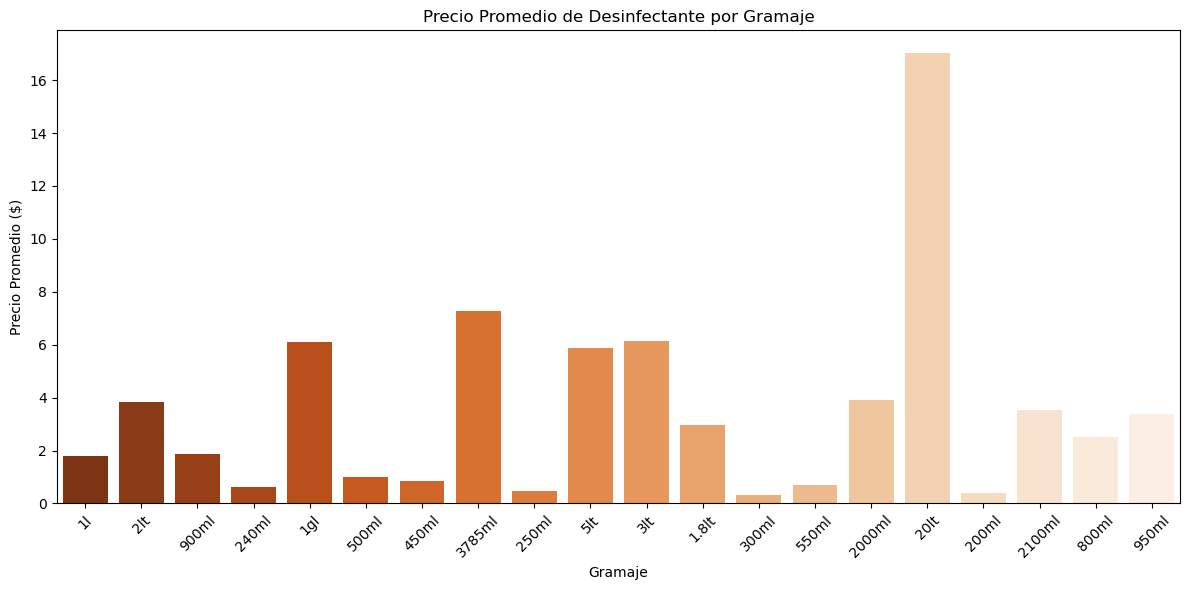

In [67]:
# Gráfico de precio promedio por gramaje
plt.figure(figsize=(12,6))
sns.barplot(
    data=gramaje_resumen,
    x="gramaje",
    y="precio_promedio",
    palette="Oranges_r"
)
plt.title("Precio Promedio de Desinfectante por Gramaje")
plt.xlabel("Gramaje")
plt.ylabel("Precio Promedio ($)")
plt.xticks(rotation=45)
plt.tight_layout()

# Guardar la imagen
plt.savefig("../images/desinfectante_precio_vs_gramaje.png", dpi=300)
plt.show()

Tendencia general

En términos absolutos, los envases de mayor volumen (por ejemplo, 20L) tienen el precio total más alto.

Los envases pequeños (200 ml, 240 ml, 250 ml, 300 ml, etc.) tienen precios mucho más bajos.

2️⃣ Precio más alto

20L es el más costoso (alrededor de $17).

Luego aparecen volúmenes grandes como 5L y 3L con precios alrededor de $6.

3️⃣ Precio más bajo

Presentaciones pequeñas como 240 ml, 250 ml, 300 ml, 200 ml están por debajo de $1.

Son las opciones más económicas en precio total.

4️⃣ Comparaciones interesantes

1 galón (1gl) cuesta aproximadamente $6, similar a 3L y 5L.

2000 ml (2L) cuesta alrededor de $4.

Algunos tamaños similares no siguen una proporción exacta, lo que sugiere diferencias por marca o presentación.